# code to run pseudobulk deg analysis in converters of longitudinal ALTRA cohort

## related to Fig 2 C&D, S7A, Fig 4A, Fig 5F

- normalized the count by deseq2
- model formula in female converters **count ~ age_conv + bmi_conv + days_to_conversion +
  (1 | subject.subjectGuid)**


In [ ]:
# load packages
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("Seurat")
quiet_library("tidyverse")
quiet_library("ggplot2")
quiet_library("Matrix")
quiet_library("dplyr")
quiet_library("viridis")
quiet_library("MAST")
quiet_library("scran")
quiet_library("data.table")
quiet_library("SingleCellExperiment")
quiet_library("SeuratDisk")
quiet_library("DESeq2")
quiet_library("parallel")
quiet_library("broom.mixed")


Warning message:
“package ‘dplyr’ was built under R version 4.3.3”
Warning message:
“package ‘scran’ was built under R version 4.3.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”


In [ ]:
set.seed(1234)


In [ ]:
# define working path
data_path <- "/home/workspace/data/ra_longitudinal/scrna/certPro"
fig_path <- "/home/workspace/data/ra_longitudinal/figures/certPro"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
output_path <- "/home/workspace/data/ra_longitudinal/output_results/certPro"
proj_name <- "ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_"


In [ ]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)


In [ ]:
source("/home/jupyter/github/ra-longitudinal/scRNA/ALTRA_scRNA_R_helper_functions.r")


# load data


In [ ]:
# download pseudobulk data
hise::cacheFiles(list("6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1"))


[1] "downloading fileID 6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1"


[1] "/home/workspace/input/569004694/UCSDCU_Y4/6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1/ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM3_psedobulk_object_list.rds"

In [ ]:
# load aim3 psudobulk data
aim3_pb <- readRDS(file.path(
  data_path,
  "ALTRA_scRNA_AIFI_L3_Pseudobulk_certPro_AIM3_psedobulk_object_list.rds"
))


In [ ]:
aim3_pb[[1]]


class: SummarizedExperiment 
dim: 970 5 
metadata(0):
assays(1): counts
rownames(970): AC004687.1 AC245014.3 ... ZNF706 ZRANB2
rowData names(0):
colnames: NULL
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

`stat_bin()` using `bins = 30`. Pick better value with `binwidth`.


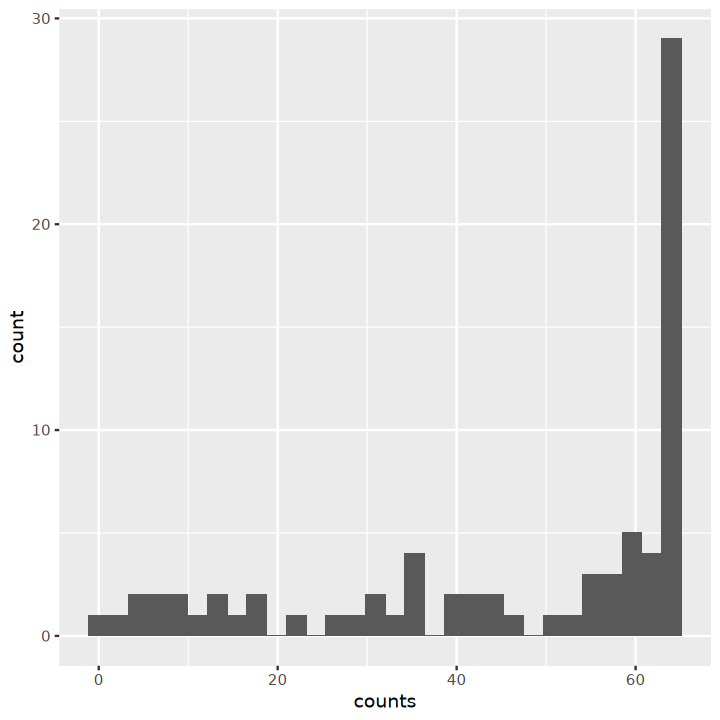

In [ ]:
# check home many samples are present for each cell type
options(repr.plot.width = 6, repr.plot.height = 6)
sample_numbers <- lapply(aim3_pb, ncol) %>%
  as.list() %>%
  as_tibble() %>%
  pivot_longer(
    cols = where(is.numeric),
    names_to = "cell_type", values_to = "counts"
  )
sample_numbers %>% ggplot(aes(x = counts)) +
  geom_histogram()


## select celltypes that have enough samples to run the models


In [ ]:
# extract the metadata
metadata <- lapply(aim3_pb, function(x) {
  meta <- colData(x) %>% as_tibble()
}) %>% rbindlist()
metadata %>% colnames()


[1] "index"                               "batch_id"                           
 [3] "hto_barcode"                         "hto_category"                       
 [5] "pbmc_sample_id"                      "pool_id"                            
 [7] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
 [9] "subject.subjectGuid"                 "subject.biologicalSex"              
[11] "subject.race"                        "subject.ethnicity"                  
[13] "subject.birthYear"                   "sample.visitName"                   
[15] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[17] "sample.daysSinceFirstVisit"          "file.id"                            
[19] "subset_grp"                          "predicted_doublet"                  
[21] "AIFI_L3"                             "doublets_manual"                    
[23] "AIFI_L3_new"                         "Status_Xsec"                        
[25] "Status_Long"                         "anti_ccp3_finalCombined"            
[27] "days_to_conversion"                  "BMI"                                
[29] "CMV_Status_Subj"                     "age_conv"                           
[31] "bmi_conv"                            "file.batchID"                       
[33] "status"                              "psbulk_n_cells"                     
[35] "psbulk_counts"

In [ ]:
# filter the metadata by as least 2 samples per donor to run longitudinal analysis
lg_meta <- metadata %>%
  group_by(AIFI_L3_new, subject.subjectGuid) %>%
  tally(name = "sample_number") %>%
  filter(sample_number >= 2) %>%
  ungroup() %>%
  group_by(AIFI_L3_new) %>%
  tally(name = "donor_number")
lg_meta %>%
  arrange(donor_number) %>%
  head(10)


AIFI_L3_new,donor_number
<chr>,<int>
Activated memory B cell,1
ISG+ memory CD4 T cell_uk1_CD8,1
Memory CD8 Treg,1
KLRB1+ memory CD8 Treg,2
KLRF1+_GZMB+_CD27-_EM_CD8_uk2,2
ISG+ cDC2,3
ISG+ naive CD8 T cell,3
SOX4+ Vd1 gdT,3
ILC,4


In [ ]:
# get cell types which have enough sample number to run the model
# celltypes_large <- sample_numbers%>%filter(counts>=30)%>%pull(cell_type)
# filter the celltype by as least 3 donors that have more than 2 samples per donor
celltypes_large <- lg_meta %>%
  filter(donor_number >= 3) %>%
  pull(AIFI_L3_new)
celltypes_large %>% length()
celltypes_drop <- metadata %>%
  filter(!AIFI_L3_new %in% celltypes_large) %>%
  pull(AIFI_L3_new) %>%
  unique()
# check what cell types are dropped from the analysis
celltypes_drop


[1] 70

[1] "Activated memory B cell"        "GZMK+ memory CD4 Treg"         
[3] "ISG+ MAIT"                      "ISG+ memory CD4 T cell_uk1_CD8"
[5] "KLRB1+ memory CD8 Treg"         "KLRF1+_GZMB+_CD27-_EM_CD8_uk2" 
[7] "Memory CD8 Treg"

In [ ]:
aim3_pb


$`Activated memory B cell`
class: SummarizedExperiment 
dim: 970 5 
metadata(0):
assays(1): counts
rownames(970): AC004687.1 AC245014.3 ... ZNF706 ZRANB2
rowData names(0):
colnames: NULL
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

$`Adaptive NK cell`
class: SummarizedExperiment 
dim: 3528 62 
metadata(0):
assays(1): counts
rownames(3528): AAK1 AASDHPPT ... ZSWIM7 ZYX
rowData names(0):
colnames: NULL
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

$`Adaptive NK cell_uk1_T`
class: SummarizedExperiment 
dim: 2008 17 
metadata(0):
assays(1): counts
rownames(2008): AAK1 AATF ... ZNRD1 ZRANB2
rowData names(0):
colnames: NULL
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

$`C1Q+ CD16 monocyte`
class: SummarizedExperiment 
dim: 4238 64 
metadata(0):
assays(1): counts
rownames(4238): AAK1 AAMP ... ZSWIM7 ZYX
rowData names(0):
colnames: NULL
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

$`CD14+ cDC2`
class: Su

In [ ]:
# remove samples beyond -750 from conversion
aim3_pb_fl <- lapply(aim3_pb[celltypes_large], function(x) {
  x <- x[, colData(x)$days_to_conversion >= (-750)]
  return(x)
})


In [ ]:
colData(aim3_pb_fl[["Core naive CD4 T cell"]]) %>% colnames()
colData(aim3_pb_fl[["Core naive CD4 T cell"]])$subject.subjectGuid %>%
  unique() %>%
  length()


[1] "index"                               "batch_id"                           
 [3] "hto_barcode"                         "hto_category"                       
 [5] "pbmc_sample_id"                      "pool_id"                            
 [7] "sample.sampleKitGuid"                "cohort.cohortGuid"                  
 [9] "subject.subjectGuid"                 "subject.biologicalSex"              
[11] "subject.race"                        "subject.ethnicity"                  
[13] "subject.birthYear"                   "sample.visitName"                   
[15] "sample.drawDate"                     "sample.diseaseStatesRecordedAtVisit"
[17] "sample.daysSinceFirstVisit"          "file.id"                            
[19] "subset_grp"                          "predicted_doublet"                  
[21] "AIFI_L3"                             "doublets_manual"                    
[23] "AIFI_L3_new"                         "Status_Xsec"                        
[25] "Status_Long"                         "anti_ccp3_finalCombined"            
[27] "days_to_conversion"                  "BMI"                                
[29] "CMV_Status_Subj"                     "age_conv"                           
[31] "bmi_conv"                            "file.batchID"                       
[33] "status"                              "psbulk_n_cells"                     
[35] "psbulk_counts"

[1] 15

In [ ]:
# run deseq to get normalized counts
aim3_pb_deseq <- DEseqNormCount(aim3_pb_fl, cores = 20)


In [ ]:
aim3_pb_deseq


$`Adaptive NK cell`
class: SummarizedExperiment 
dim: 3528 56 
metadata(0):
assays(2): counts vst
rownames(3528): AAK1 AASDHPPT ... ZSWIM7 ZYX
rowData names(0):
colnames(56): KT00052 KT00056 ... KT04474 KT04924
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

$`Adaptive NK cell_uk1_T`
class: SummarizedExperiment 
dim: 2008 17 
metadata(0):
assays(2): counts vst
rownames(2008): AAK1 AATF ... ZNRD1 ZRANB2
rowData names(0):
colnames(17): KT00057 KT00084 ... KT02975 KT04085
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

$`C1Q+ CD16 monocyte`
class: SummarizedExperiment 
dim: 4238 58 
metadata(0):
assays(2): counts vst
rownames(4238): AAK1 AAMP ... ZSWIM7 ZYX
rowData names(0):
colnames(58): KT00052 KT00056 ... KT04474 KT04924
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

$`CD14+ cDC2`
class: SummarizedExperiment 
dim: 6757 59 
metadata(0):
assays(2): counts vst
rownames(6757): A1BG AAED1 ... ZYX ZZEF1
rowData names(0):
colnames(5

In [ ]:
# save the input deseq2 normalized data to run the model
aim3_pb_deseq %>% saveRDS(file.path(
  data_path,
  paste0(proj_name, "_deseq2_norm_counts_list.rds")
))


In [ ]:
# load the input deseq2 normalized data to run the model
aim3_pb_deseq <- readRDS(file.path(
  data_path,
  paste0(proj_name, "_deseq2_norm_counts_list.rds")
))


## run model in all samples (not used)


In [ ]:
# # run deg model in all cell types
# formula = as.formula('count ~  age_conv + bmi_conv + subject.biologicalSex + days_to_conversion +
#     (1 | subject.subjectGuid)')
# output_path = '/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/deepclean/model_output/750days'
# model_res <- lapply(aim3_pb_deseq,
#                     runLme4Celltype, formula=formula,
#                     assays='vst', celltype_col = 'AIFI_L3_new',
#                     cores=15, output_path=output_path, proj_name=proj_name)


In [ ]:
# # check which cell type didn't run; sometime the model stop due to run time?
# celltypes_run<-list.files(output_path)%>%
#     str_subset('vst_models_results.csv') %>% str_remove('ALTRA_AIM3_converters_scRNA_Pseudobulk_AIFI_l3__')%>%
#     str_remove('_lme4_vst_models_results.csv')
# celltypes_rerun<-celltypes_large[!celltypes_large%in%celltypes_run]
# celltypes_rerun <- celltypes_rerun[celltypes_rerun!='Naive_Vd1_gdT']
# celltypes_rerun
# celltypes_run%>%length()


In [ ]:
# # run deg model in all cell types - rerun
# model_res <- lapply(aim3_pb_deseq[celltypes_rerun],
#                     runLme4Celltype, formula=formula,
#                     assays='vst', celltype_col = 'AIFI_L3_new',
#                     cores=59)


## run model only with female subject within 750 days


In [ ]:
# remove samples above 750 days
# remove all male subject
aim3_pb_female <- lapply(aim3_pb_deseq, function(x) {
  x <- x[, colData(x)$subject.biologicalSex == "Female"]
  x <- x[, colData(x)$days_to_conversion >= (-750)]
  return(x)
})


In [ ]:
colData(aim3_pb_female[["Core naive CD4 T cell"]])$subject.subjectGuid %>%
  unique() %>%
  length()
aim3_pb_female[["CM CD4 T cell"]]


[1] 13

class: SummarizedExperiment 
dim: 5497 50 
metadata(0):
assays(2): counts vst
rownames(5497): A1BG AAED1 ... ZYX ZZEF1
rowData names(0):
colnames(50): KT00052 KT00056 ... KT04474 KT04924
colData names(35): index batch_id ... psbulk_n_cells psbulk_counts

In [ ]:
# run deg model in all cell types
formula <- as.formula("count ~  age_conv + bmi_conv + days_to_conversion +
    (1 | subject.subjectGuid)")
# define the output path to same the model results
output_path <- "/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/certPro/model_output"

model_res <- lapply(aim3_pb_female,
  runLme4Celltype,
  formula = formula,
  assays = "vst", celltype_col = "AIFI_L3_new",
  cores = 59, output_path = output_path, proj_name = proj_name
)


Run lme4 model deseq2 norm counts for cell type Adaptive NK cell

FIt glmm model  deseq2 norm counts for  3528 genes

Run lme4 model deseq2 norm counts for cell type Adaptive NK cell_uk1_T

FIt glmm model  deseq2 norm counts for  2008 genes

Run lme4 model deseq2 norm counts for cell type C1Q+ CD16 monocyte

FIt glmm model  deseq2 norm counts for  4238 genes

Run lme4 model deseq2 norm counts for cell type CD27+ effector B cell

FIt glmm model  deseq2 norm counts for  4302 genes

Run lme4 model deseq2 norm counts for cell type CD27- effector B cell

FIt glmm model  deseq2 norm counts for  2354 genes

Run lme4 model deseq2 norm counts for cell type CD4 MAIT

FIt glmm model  deseq2 norm counts for  2183 genes

Run lme4 model deseq2 norm counts for cell type CD56bright NK cell

FIt glmm model  deseq2 norm counts for  5093 genes

Run lme4 model deseq2 norm counts for cell type CD8 MAIT

FIt glmm model  deseq2 norm counts for  6163 genes

Run lme4 model deseq2 norm counts for cell type CD8a

In [ ]:
# check which cell type didn't run
# run deg model in all cell types
celltypes_large <- names(aim3_pb_female)
celltypes_run <- list.files(output_path) %>%
  str_subset("vst_models_results.csv") %>%
  str_remove("ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3__") %>%
  str_remove("_lme4_vst_models_results.csv")
celltypes_rerun <- celltypes_large[!celltypes_large %in% celltypes_run]
# celltypes_rerun <- celltypes_rerun[celltypes_rerun!='Naive_Vd1_gdT']
celltypes_rerun %>% length()
celltypes_large %>% length()


[1] 0

[1] 70

# Summarize modeling results and do some analysis


In [ ]:
# load all the modeling results
model_files <- list.files(output_path,
  pattern = "*vst_models_results.csv",
  full.names = TRUE
)
model_res <- lapply(model_files, fread) %>% rbindlist()


In [ ]:
# model_res


In [ ]:
model_res %>%
  distinct(celltype) %>%
  nrow()


[1] 70

In [ ]:
# combine all model results and save
model_res %>%
  write_csv(file.path(
    "/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/certPro",
    paste0(proj_name, "_all_variables_result_750days.csv")
  ))


In [ ]:
# get the result associated with time and do fdr adjustment
model_res_time <- model_res %>%
  filter(term == "days_to_conversion") %>%
  group_by(celltype) %>%
  rstatix::adjust_pvalue(
    p.col = "p.value", method = "BH",
    output.col = "p_adj_days_to_conversion"
  ) %>%
  ungroup()
# model_res_time%>%group_by(celltype, sig)%>%filter(sig!='ns')%>% tally()


In [ ]:
# calculate the qvalues
# library(qvalue)
calQvalue <- function(x) {
  # test
  pvalues <- x %>% pull(p.value)
  qvalues <- qvalue::qvalue(pvalues)$qvalues
  x <- x %>% mutate("q_values" = qvalues)
  return(x)
}

model_res_time_qvalue <- model_res_time %>%
  group_by(celltype) %>%
  group_modify(~ calQvalue(.x)) %>%
  rstatix::add_significance(
    p.col = "q_values", output.col = "sig",
    cutpoints = c(0, 0.05, 0.2, 1),
    symbols = c("*", "<0.2", "ns")
  )


In [ ]:
model_res_time_qvalue %>% head()


celltype,effect,group,term,estimate,std.error,statistic,df,p.value,gene,p_adj_days_to_conversion,q_values,sig
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<chr>
Adaptive NK cell,fixed,NA,days_to_conversion,-4.601178e-04,0.0001726325,-2.6653027,43.00000,0.01079008,AAK1,0.4335398,0.3471929,ns
Adaptive NK cell,fixed,NA,days_to_conversion,2.698218e-04,0.0001816877,1.4850857,43.00000,0.14481591,AASDHPPT,0.6248914,0.5004335,ns
Adaptive NK cell,fixed,NA,days_to_conversion,-1.742457e-05,0.0001246150,-0.1398272,42.98683,0.88944965,AATF,0.9806182,0.7853112,ns
Adaptive NK cell,fixed,NA,days_to_conversion,-1.164469e-04,0.0001820954,-0.6394831,41.24902,0.52604448,ABCB1,0.8860607,0.7095864,ns
Adaptive NK cell,fixed,NA,days_to_conversion,-2.050641e-04,0.0002058161,-0.9963461,43.00000,0.32465598,ABCE1,0.7777938,0.6228828,ns
Adaptive NK cell,fixed,NA,days_to_conversion,-3.740837e-06,0.0001426124,-0.0262308,43.00000,0.97919461,ABCF1,0.9929861,0.7952158,ns


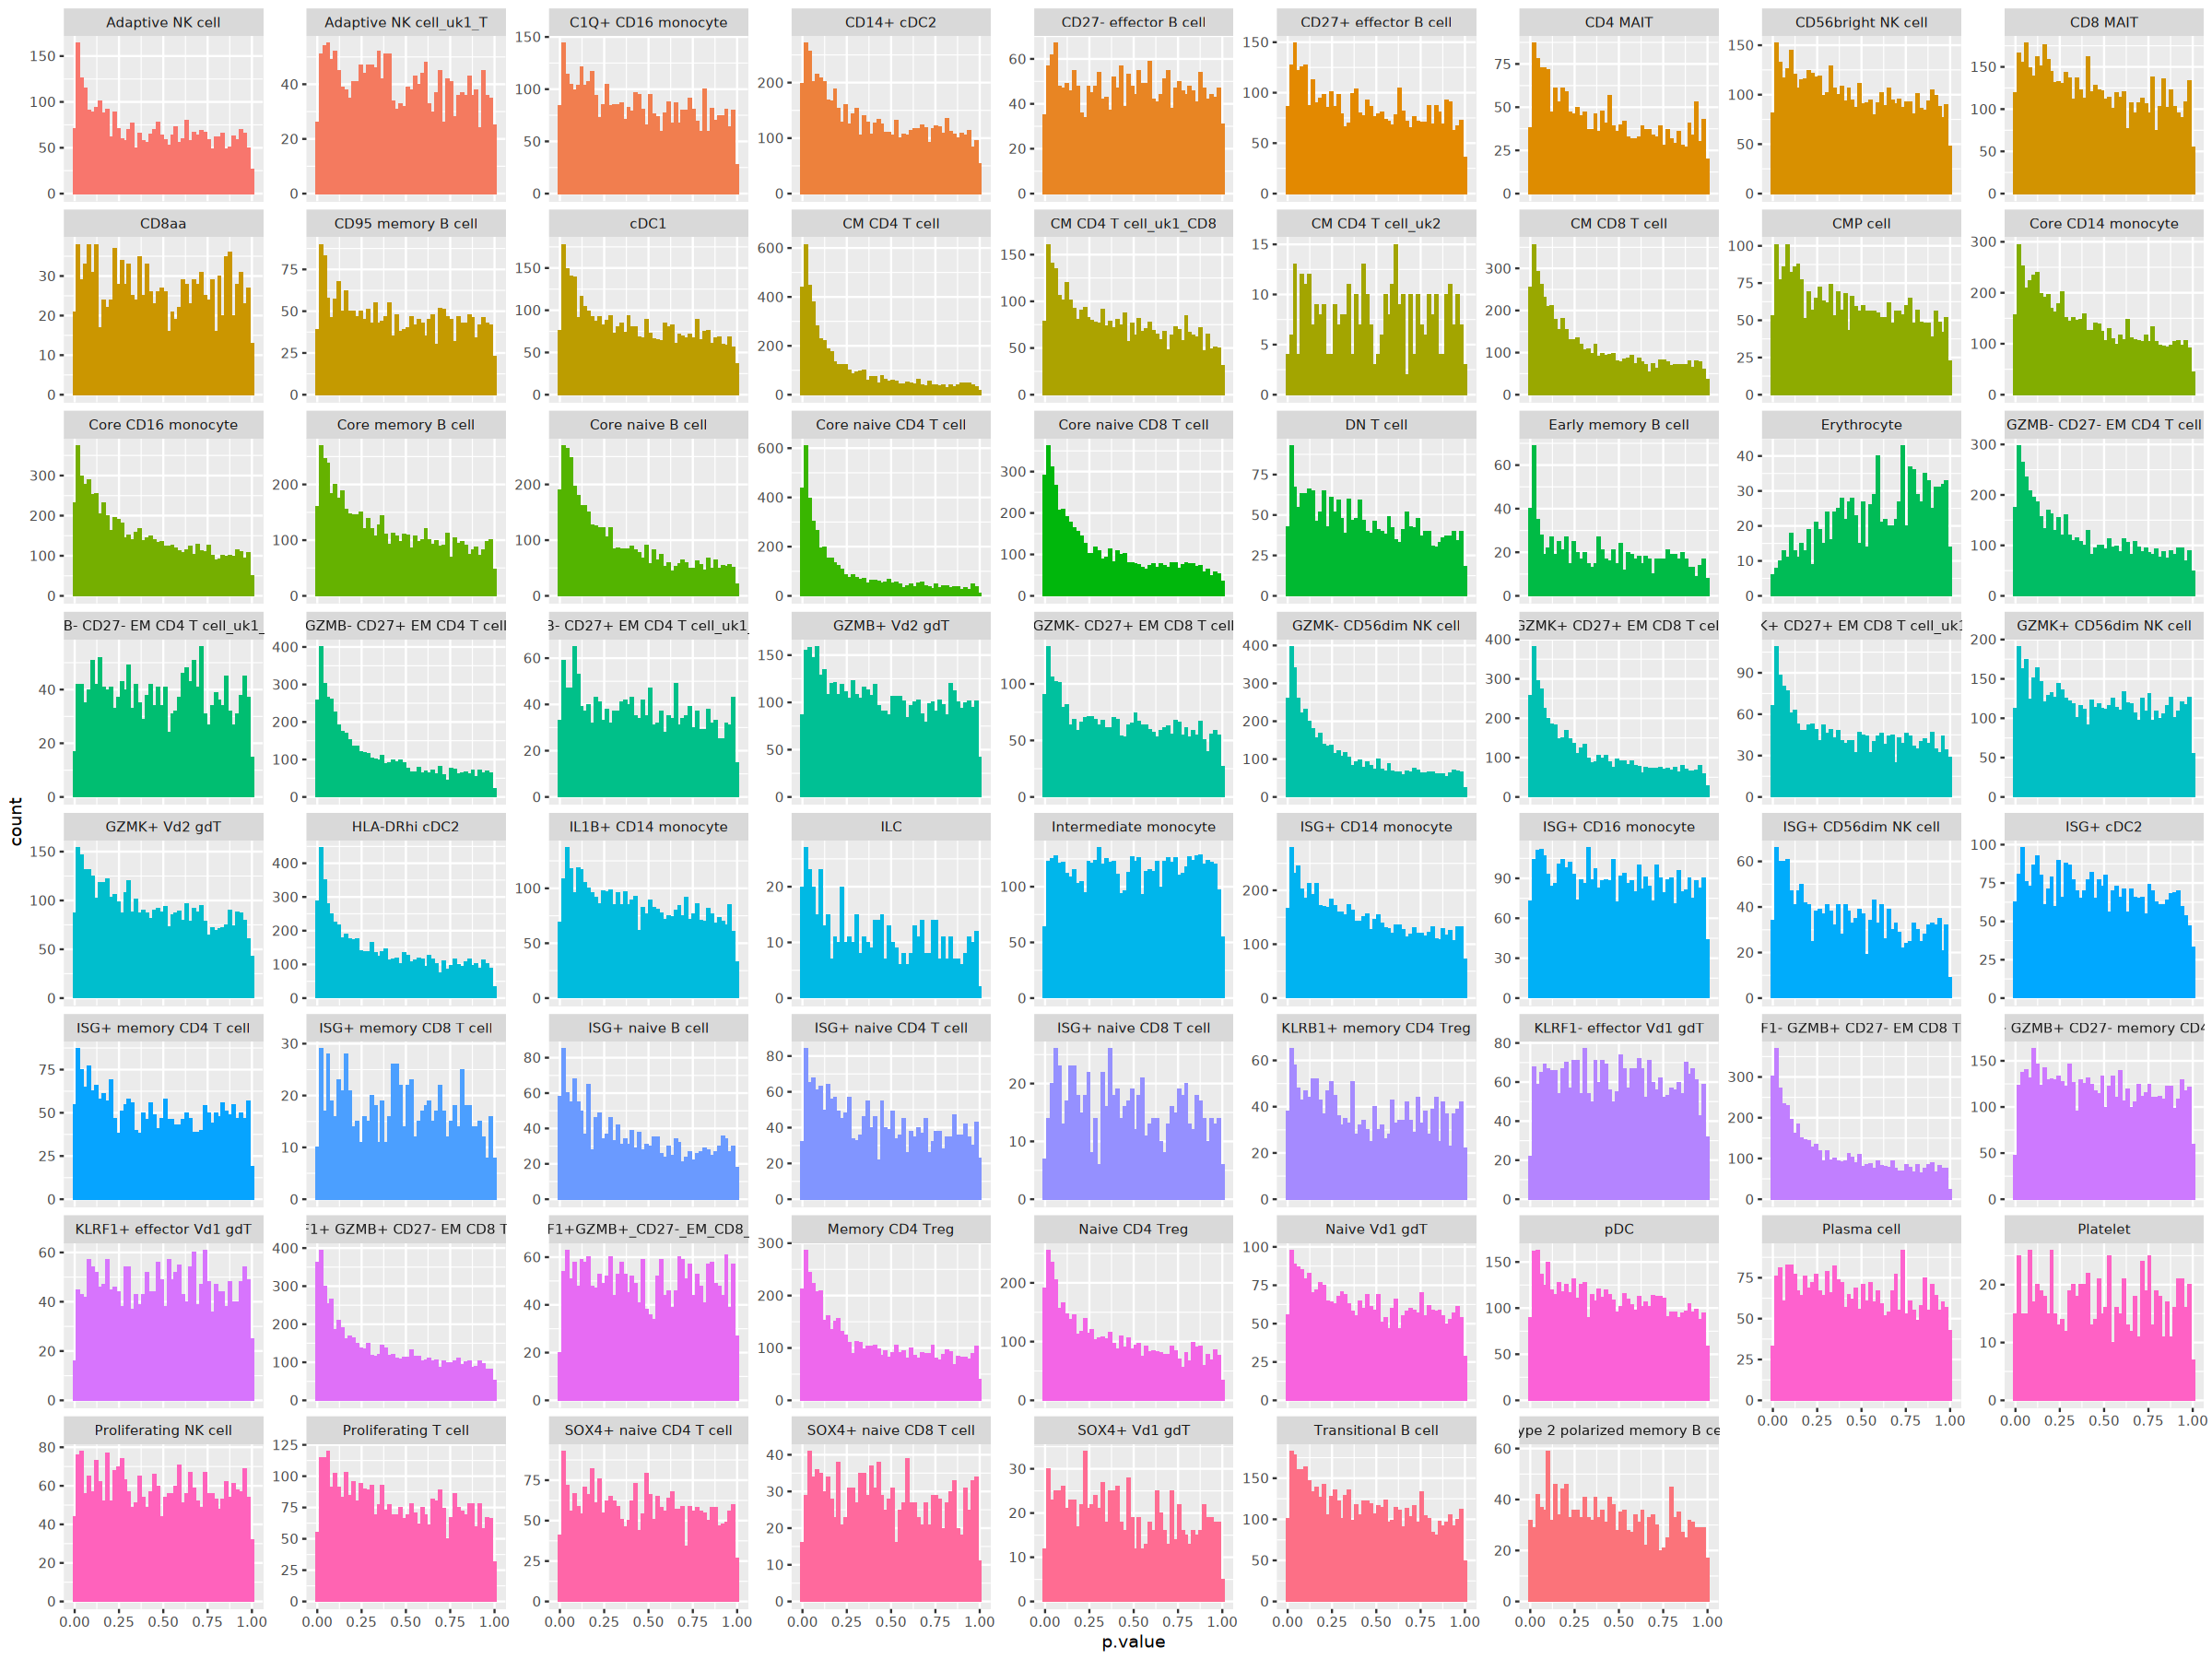

In [ ]:
# plot the p values
options(repr.plot.width = 20, repr.plot.height = 15)
model_res_time_qvalue %>% ggplot(aes(x = p.value, fill = celltype)) +
  geom_histogram(bins = 50) +
  facet_wrap(vars(celltype), scales = "free_y") +
  theme(legend.position = "none")

ggsave(file.path(fig_path, paste0(proj_name, "_p_values_distribution_lme4_model_all_female.png")),
  width = 16, height = 12
)


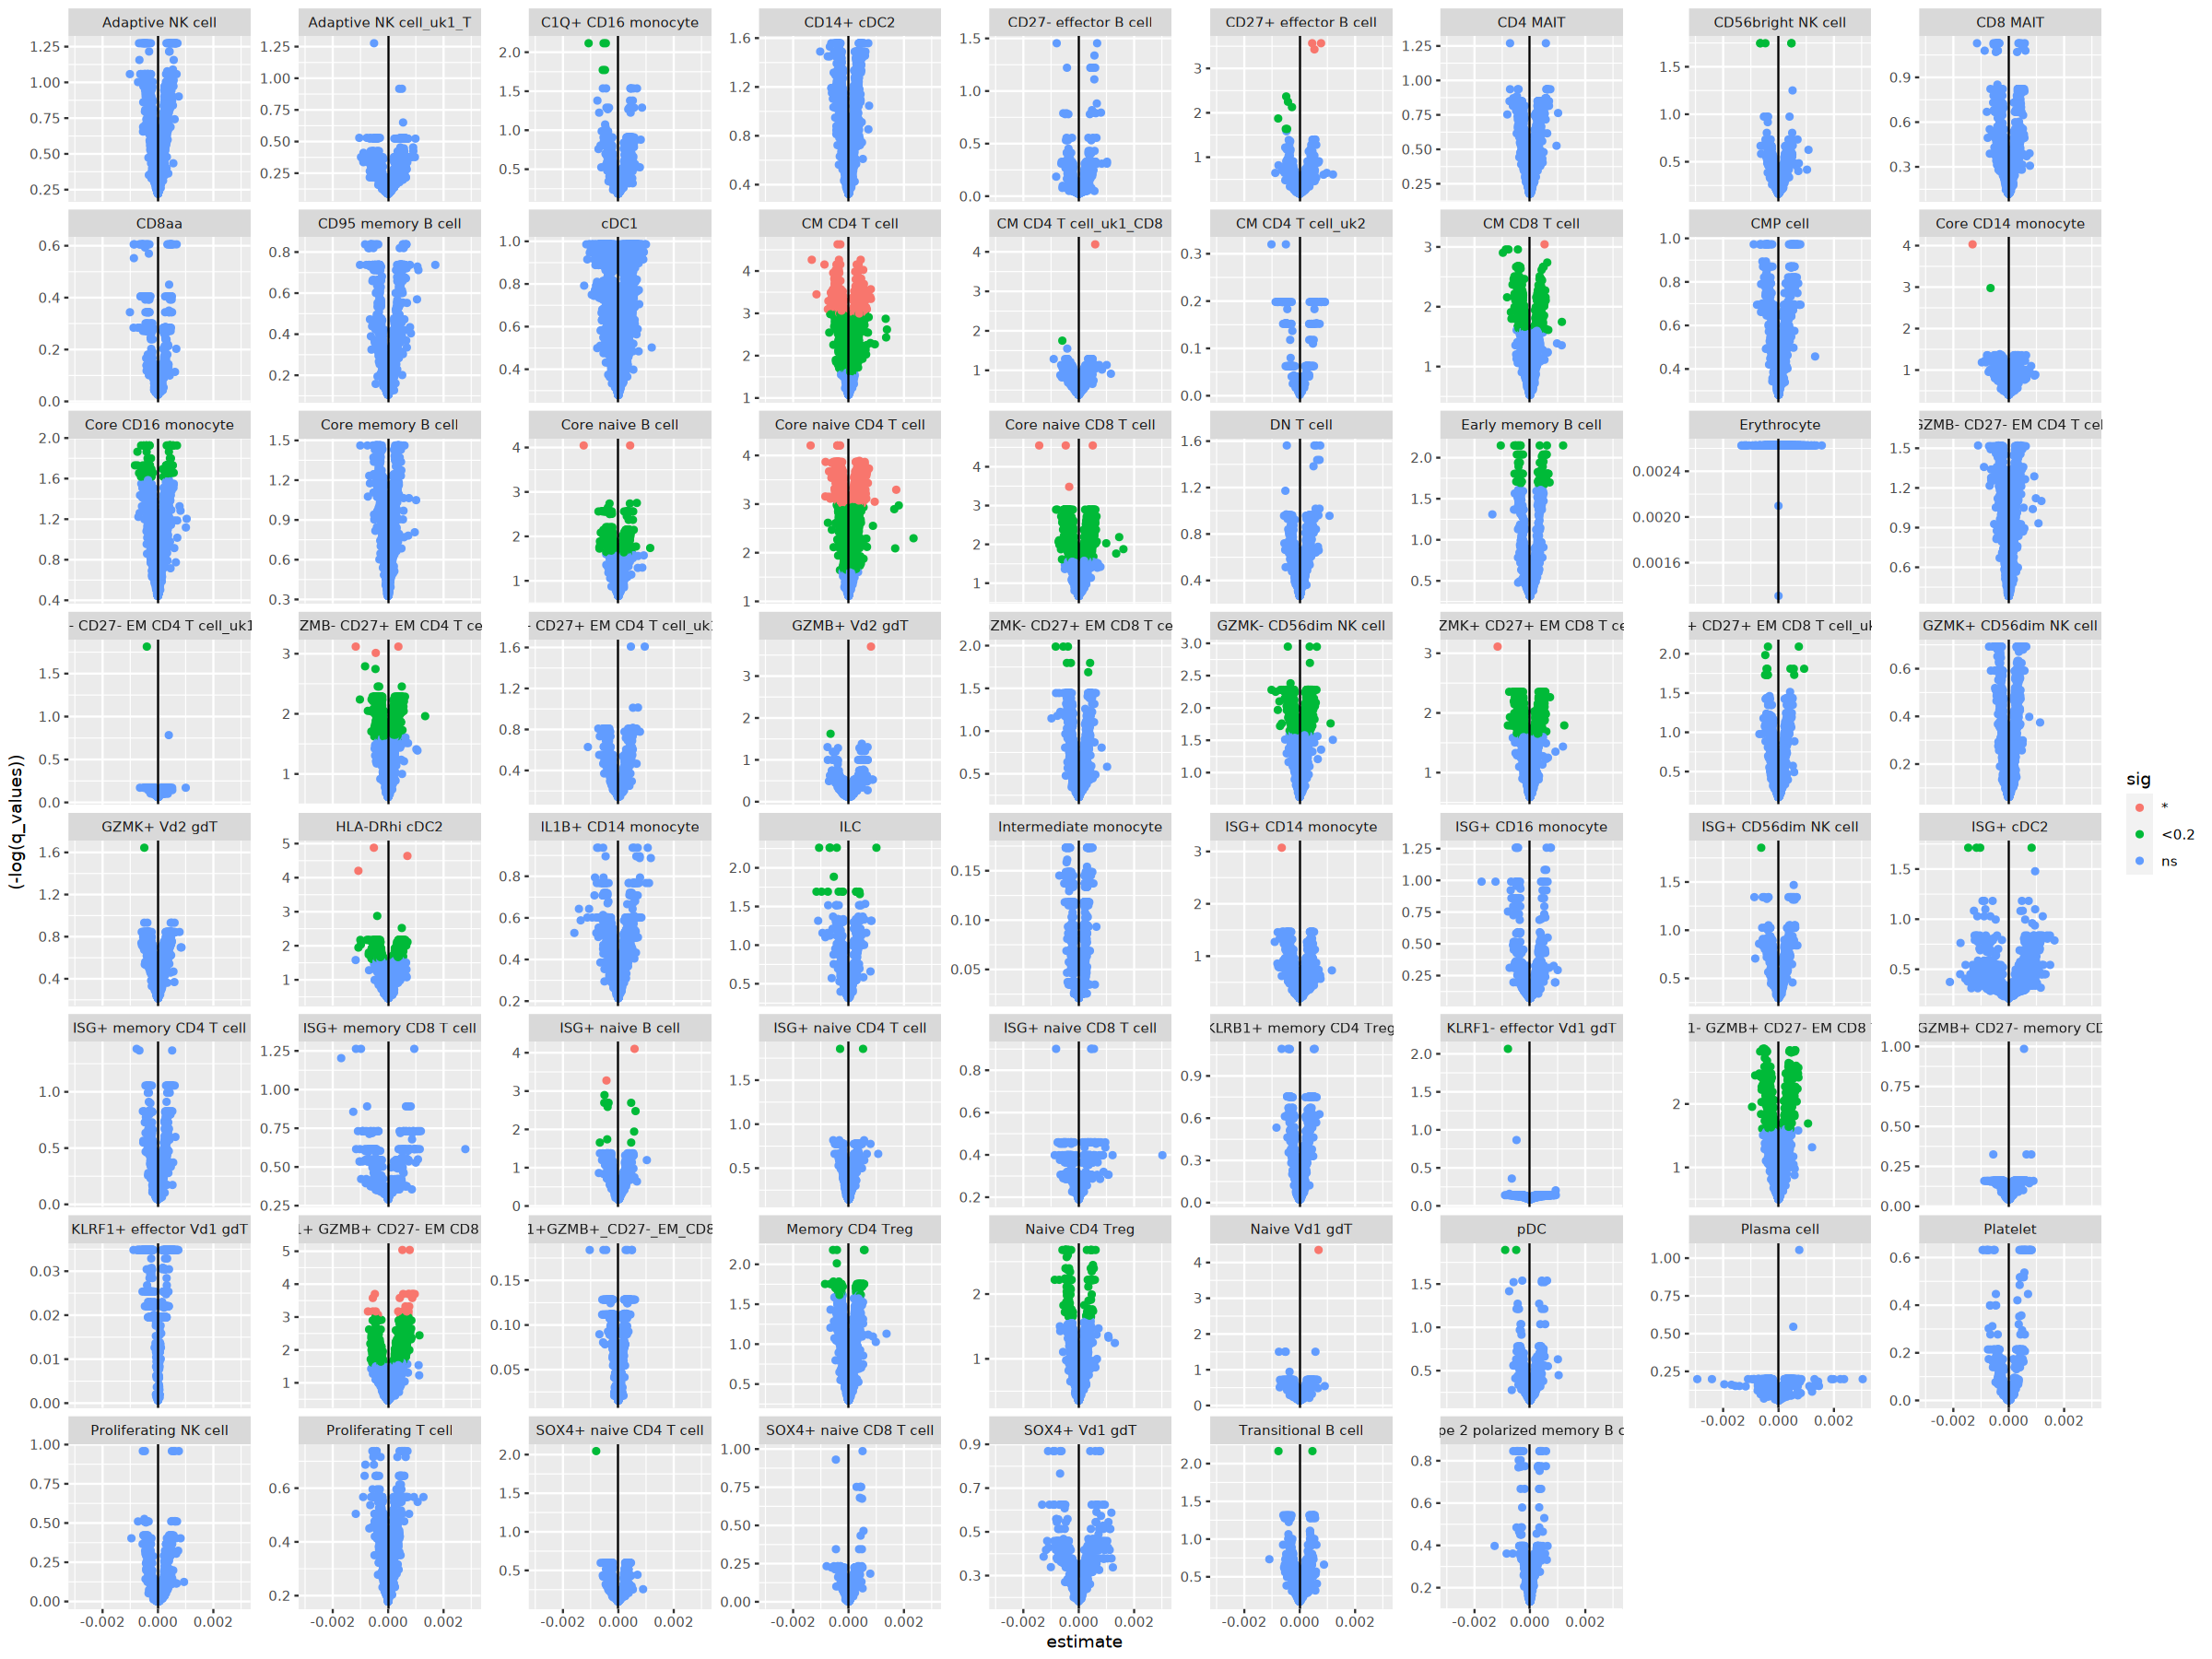

In [ ]:
# plot the volcano plot
model_res_time_qvalue %>%
  ggplot(aes(
    x = estimate, y = (-log(q_values)),
    color = sig
  )) +
  geom_point() +
  facet_wrap(vars(celltype), scale = "free_y") +
  geom_vline(xintercept = 0)
ggsave(file.path(fig_path, paste0(proj_name, "_deseq2_mixed_model_volcano_plot_all_female.png")),
  width = 16, height = 8
)


In [ ]:
# save the model results
model_res_time_qvalue %>%
  select(-p_adj_days_to_conversion) %>%
  write_csv(file.path(output_path, paste0(proj_name, "mixed_models_time_result_750days.csv")))


### upload AIM3 deg results to collab


In [ ]:
# upload AIM3 deg results to collab
hise::uploadFiles(
    files = list("/home/workspace/data/ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3_mixed_models_time_result_750days.csv"),
    studySpaceId = "223de760-9624-45bd-aefe-ca24c75b1800",
    title = "ALTRA AIM3 DEG results",
    inputFileIds = as.list("6f47ba16-4bfd-4ab1-b0c9-2add3fa72cc1")
)


## pathway analysis


In [ ]:
# save the model results
aim3_degs <- read_csv(file.path(output_path, paste0(proj_name, "mixed_models_time_result_750days.csv")),
  show_col_types = FALSE
) %>%
  mutate(log_pval_dir = -log(p.value) * sign(estimate)) %>%
  rename("celltype" = "cell_type")


In [ ]:
aim3_degs %>% head()


cell_type,effect,group,term,estimate,std.error,statistic,df,p.value,gene,q_values,sig,log_pval_dir
<chr>,<chr>,<lgl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>
Adaptive NK cell,fixed,NA,days_to_conversion,-4.601178e-04,0.0001726325,-2.6653027,43.00000,0.01079008,AAK1,0.3471929,ns,-4.52912836
Adaptive NK cell,fixed,NA,days_to_conversion,2.698218e-04,0.0001816877,1.4850857,43.00000,0.14481591,AASDHPPT,0.5004335,ns,1.93229191
Adaptive NK cell,fixed,NA,days_to_conversion,-1.742457e-05,0.0001246150,-0.1398272,42.98683,0.88944965,AATF,0.7853112,ns,-0.11715238
Adaptive NK cell,fixed,NA,days_to_conversion,-1.164469e-04,0.0001820954,-0.6394831,41.24902,0.52604448,ABCB1,0.7095864,ns,-0.64236951
Adaptive NK cell,fixed,NA,days_to_conversion,-2.050641e-04,0.0002058161,-0.9963461,43.00000,0.32465598,ABCE1,0.6228828,ns,-1.12498918
Adaptive NK cell,fixed,NA,days_to_conversion,-3.740837e-06,0.0001426124,-0.0262308,43.00000,0.97919461,ABCF1,0.7952158,ns,-0.02102487


In [ ]:
aim3_degs %>%
  filter(q_values < 0.1 & q_values > 0.05) %>%
  group_by(cell_type) %>%
  tally()


cell_type,n
<chr>,<int>
CD27+ effector B cell,1
CM CD4 T cell,1945
CM CD8 T cell,45
Core CD14 monocyte,1
Core naive B cell,43
Core naive CD4 T cell,1472
Core naive CD8 T cell,301
GZMB- CD27+ EM CD4 T cell,5
GZMK+ CD27+ EM CD8 T cell,58


In [ ]:
# only do pathway analysis for at least 30 degs
deg_counts <- aim3_degs %>%
  mutate(significance = if_else(q_values < 0.1, "sig", "ns")) %>%
  group_by(cell_type, significance) %>%
  tally()
celltypes <- deg_counts %>%
  filter(significance == "sig" & n > 5) %>%
  pull(cell_type)
celltypes


[1] "CM CD4 T cell"                    "CM CD8 T cell"                   
 [3] "Core naive B cell"                "Core naive CD4 T cell"           
 [5] "Core naive CD8 T cell"            "GZMB- CD27+ EM CD4 T cell"       
 [7] "GZMK+ CD27+ EM CD8 T cell"        "ISG+ naive B cell"               
 [9] "KLRF1+ GZMB+ CD27- EM CD8 T cell" "KLRF1- GZMB+ CD27- EM CD8 T cell"
[11] "Naive CD4 Treg"

In [ ]:
# run collapsed pathway
aim3_pw_collap <- aim3_degs %>%
  filter(cell_type %in% celltypes) %>%
  RunGSEACelltype(
    ct.col = "cell_type", rank.col = "log_pval_dir",
    gene.col = "gene",
    collapsePathways = FALSE, ncores = 15
  )


run GSEA in CM CD4 T cell

run GSEA in 5497 genes



  |======================================================================| 100%



run GSEA in CM CD8 T cell

run GSEA in 5844 genes



  |======================================================================| 100%



run GSEA in Core naive B cell

run GSEA in 4791 genes



...

  |===========================================                           |  61%R_zmq_msg_send errno: 4 strerror: Interrupted system call
  |======================================================================| 100%



run GSEA in KLRF1- GZMB+ CD27- EM CD8 T cell

run GSEA in 5810 genes



  |======================================================================| 100%



run GSEA in Naive CD4 Treg

run GSEA in 5353 genes



  |======================================================================| 100%



In [ ]:
aim3_pw_collap %>%
  select(-leadingEdge) %>%
  tail()


pathway,pval,padj,NES,celltype,group,pID,lesize,gsize,propGenes
<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<int>,<int>,<int>,<dbl>
REACTOME_SRP_DEPENDENT_COTRANSLATIONAL_PROTEIN_TARGETING_TO_MEMBRANE,5.897541e-33,1.657209e-30,-3.090901,Naive CD4 Treg,down,1519,81,113,71.68142
KEGG_RIBOSOME,1.213216e-32,2.435097e-30,-3.121674,Naive CD4 Treg,down,1520,74,88,84.09091
WP_CYTOPLASMIC_RIBOSOMAL_PROTEINS,1.201023e-32,2.435097e-30,-3.121773,Naive CD4 Treg,down,1521,72,90,80.00000
REACTOME_RESPONSE_OF_EIF2AK4_GCN2_TO_AMINO_ACID_DEFICIENCY,1.460228e-33,6.838732e-31,-3.123086,Naive CD4 Treg,down,1522,75,102,73.52941
REACTOME_EUKARYOTIC_TRANSLATION_INITIATION,1.044317e-34,7.336326e-32,-3.131119,Naive CD4 Treg,down,1523,82,120,68.33333
REACTOME_EUKARYOTIC_TRANSLATION_ELONGATION,4.739836e-33,1.657209e-30,-3.153545,Naive CD4 Treg,down,1524,78,94,82.97872


In [ ]:
# save the pathway results
aim3_pw_collap %>% write_csv(file.path(output_path, paste0(proj_name, "AIM3_deg_gsea_pathway.csv")))


# plot gene expression


In [ ]:
# get gene expression
sce_sub <- as(pb_sub, "SingleCellExperiment")
gene_test <- "NABP1"
assay <- "vst"
# Get expression matrix
gex_exprs <- assay(sce_sub, assay)[gene_test, ]
# Set up the column annotation
gex_df <- colData(sce_sub) %>%
  as_tibble() %>%
  mutate(
    cell_type = cell_type_test,
    gene = gene_test,
    normalized_counts = gex_exprs
  )
gex_df %>% head()


index,batch_id,hto_barcode,hto_category,pbmc_sample_id,pool_id,sample.sampleKitGuid,cohort.cohortGuid,subject.subjectGuid,subject.biologicalSex,⋯,CMV_Status_Subj,age_conv,bmi_conv,file.batchID,status,psbulk_n_cells,psbulk_counts,cell_type,gene,normalized_counts
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<fct>,⋯,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<dbl>
KT00052_CM CD4 T cell,B140,ATTGACCCGCGTTAG,singlet,PB00052-02,B140-P2,KT00052,CU1,CU1009,Female,⋯,Negative,58,25.64892,B140,at_risk,2201,13382088,CM CD4 T cell,NAIP,6.940566
KT00056_CM CD4 T cell,B002,GGTTGCCAGATGTCA,singlet,PB00056-01,B002-P2,KT00056,CU1,CU1007,Female,⋯,Negative,44,26.19498,B002,at_risk,1571,9868987,CM CD4 T cell,NAIP,7.097143
KT00057_CM CD4 T cell,B002,TGTCTTTCCTGCCAG,singlet,PB00057-01,B002-P2,KT00057,CU1,CU1003,Female,⋯,Positive,23,23.14306,B002,at_risk,1103,6007831,CM CD4 T cell,NAIP,6.984394
KT00082_CM CD4 T cell,B005,TAACGACCAGCCATA,singlet,PB00082-01,B005-P1,KT00082,CU1,CU1007,Female,⋯,Negative,44,26.19498,B005,at_risk,1326,7139030,CM CD4 T cell,NAIP,7.186924
KT00084_CM CD4 T cell,B010,CTCCTCTGCAATTAC,singlet,PB00084-01,B010-P1,KT00084,CU1,CU1029,Female,⋯,Positive,66,28.67547,B010,at_risk,2848,16790739,CM CD4 T cell,NAIP,6.872802
KT00099_CM CD4 T cell,B005,TGTCTTTCCTGCCAG,singlet,PB00099-01,B005-P1,KT00099,CU1,CU1003,Female,⋯,Positive,23,23.14306,B005,at_risk,1110,5316337,CM CD4 T cell,NAIP,7.228415


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


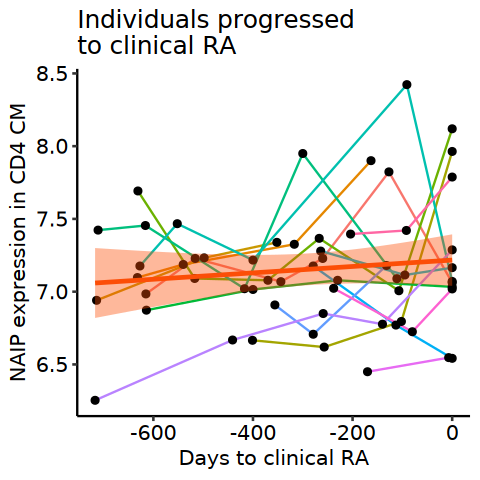

In [ ]:
options(repr.plot.width = 4, repr.plot.height = 4)
gex_df %>% ggplot(aes(x = days_to_conversion, y = normalized_counts)) +
  geom_line(aes(color = subject.subjectGuid)) +
  geom_point() +
  stat_smooth(
    color = "#FC4E07", fill = "#FC4E07",
    method = "lm"
  ) +
  ggpubr::theme_pubr() +
  guides(color = "none", fill = "none") +
  labs(
    title = "Individuals progressed\nto clinical RA",
    x = "Days to clinical RA", y = "NAIP expression in CD4 CM"
  )
ggsave(file.path(fig_path, paste0(proj_name, "_NAIP_expression.pdf")),
  width = 3, height = 3
)


## plot Fig S7A gene expression and model fit


In [ ]:
# define a function to plot linear mixed model fit for individual gene
plotFitLmer <- function(fit, gene) {
    # extract the fit data
    fit_data <- fit[[gene]]@frame
    predicted_values <- modelr::data_grid(
        fit_data, age_conv, bmi_conv,
        days_to_conversion, subject.subjectGuid
    ) %>%
        modelr::add_predictions(fit[[gene]])
    # plot the residue
    df_model <- broom.mixed::augment(fit[[gene]])
    df_model[".stdresid"] <- resid(fit[[gene]], type = "pearson")

    # plot the predicted regression line
    p2 <- fit_data %>% ggplot(aes(x = days_to_conversion, y = count)) +
        geom_line(aes(color = subject.subjectGuid)) +
        geom_point(aes(color = subject.subjectGuid)) +
        stat_smooth(
            data = predicted_values, method = "lm", se = FALSE,
            aes(x = days_to_conversion, y = pred, color = subject.subjectGuid)
        ) +
        ggtitle(gene) +
        scale_color_subj() +
        theme_bw() +
        ylab("Normalized count")
    return(p2)
}

#' Plot a frequency line plot with prediction
#'
#' This function takes a frequency table, a model fit, and various parameters to create a line plot with prediction.
#'
#' @param frequency_table A data frame containing the frequency data.
#' @param model_fit The model fit object.
#' @param palette A vector of colors for the line plot.
#' @param fig_path The file path to save the plot. Default is NULL.
#' @param fig_name The name of the figure Default is NULL.
#' @param x_var The variable for the x-axis. Default is "days_to_conversion".
#' @param y_var The variable for the y-axis. Default is "clr".
#' @param color_var The variable for coloring the lines. Default is "subject.subjectGuid".
#' @param shape_var The variable for shaping the points. Default is "sex".
#' @param title The title of the plot. Default is "Cluster 9".
#' @param x_label The label for the x-axis. Default is "Days to Conversion".
#' @param y_label The label for the y-axis. Default is "CLR".
#' @param annotation_text The text for the annotation. Default is "p=0.055".
#' @param annotation_x The x-coordinate for the annotation. Default is -600.
#' @param annotation_y The y-coordinate for the annotation. Default is 1.
#' @param annotation_color The color for the annotation. Default is "red".
#'
#' @return The plot object.
#'
#' @examples
#' # Example usage of PlotFreqLinePlot function
#' PlotFreqLinePlot(frequency_table, model_fit, palette,
#'     fig_path = "path/to/save", fig_name = "fig_name",
#'     x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
#'     shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion",
#'     y_label = "CLR", annotation_text = "p=0.055", annotation_x = -600,
#'     annotation_y = 1, annotation_color = "red"
#' )
#'
#' @export
PlotPredLinePlot <- function(model_fit, fig_path = NULL, fig_name = NULL,
                             x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
                             shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion",
                             y_label = "CLR") {
    require(ggplot2)
    require(ggeffects)

    # Extract the prediction data frame

    pred.mm <- ggpredict(model_fit, terms = c(x_var)) # Adjusted to use x_var
    fit_data <- model_fit@frame
    # plot
    p1 <- fit_data %>%
        ggplot() +
        geom_line(aes(x = .data[[x_var]], y = .data[[y_var]], color = .data[[color_var]]), size = 1) +
        geom_point(aes(x = .data[[x_var]], y = .data[[y_var]])) +
        geom_line(data = pred.mm, aes(x = x, y = predicted), color = "#8F7700FF", size = 1.2) +
        geom_ribbon(
            data = pred.mm, aes(x = x, ymin = predicted - std.error, ymax = predicted + std.error),
            fill = "#8F7700FF", alpha = 0.3, size = 1.2
        ) +
        labs(title = title) +
        xlab(x_label) +
        ylab(y_label) +
        scale_color_subj() +
        ggpubr::theme_pubr() +
        scale_shape_manual(values = c(1, 2)) +
        guides(color = FALSE)

    # Code to save the plot if fig_path and proj_name are provided
    # Check if fig_path and proj_name are provided and not empty
    if (!missing(fig_path) && !missing(fig_name) && nzchar(fig_path) && nzchar(fig_name)) {
        # Construct the full file path with the project name and desired file extension
        file_name <- paste0(fig_path, "/", fig_name)
        # Use ggsave to save the plot
        ggsave(file_name, plot = p1, width = 4, height = 4, dpi = 300)
    }
    return(p1)
}


In [ ]:
# load the model output from AIM3 deg
aim3_cm_model <- readRDS(
  "/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/certPro/model_output/ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3__CM CD4 T cell_lme4_vst_models.rds"
)
aim3_cd4na_model <- readRDS(
  "/home/jupyter/data/ra_longitudinal/output_results/pseudobulk/certPro/model_output/ALTRA_AIM3_certpro_scRNA_Pseudobulk_AIFI_l3__Core naive CD4 T cell_lme4_vst_models.rds"
)


In [ ]:
genes_plot <- c("STAT5B", "STAT2", "STIM2", "AKT3", "CD28", "FOSB")

p_list <- lapply(genes_plot, function(gene_plot) {
  p <- PlotPredLinePlot(aim3_cm_model[[gene_plot]],
    y_var = "count", shape_var = NULL,
    title = gene_plot, y_label = "Normalized expression"
  )
  return(p)
})


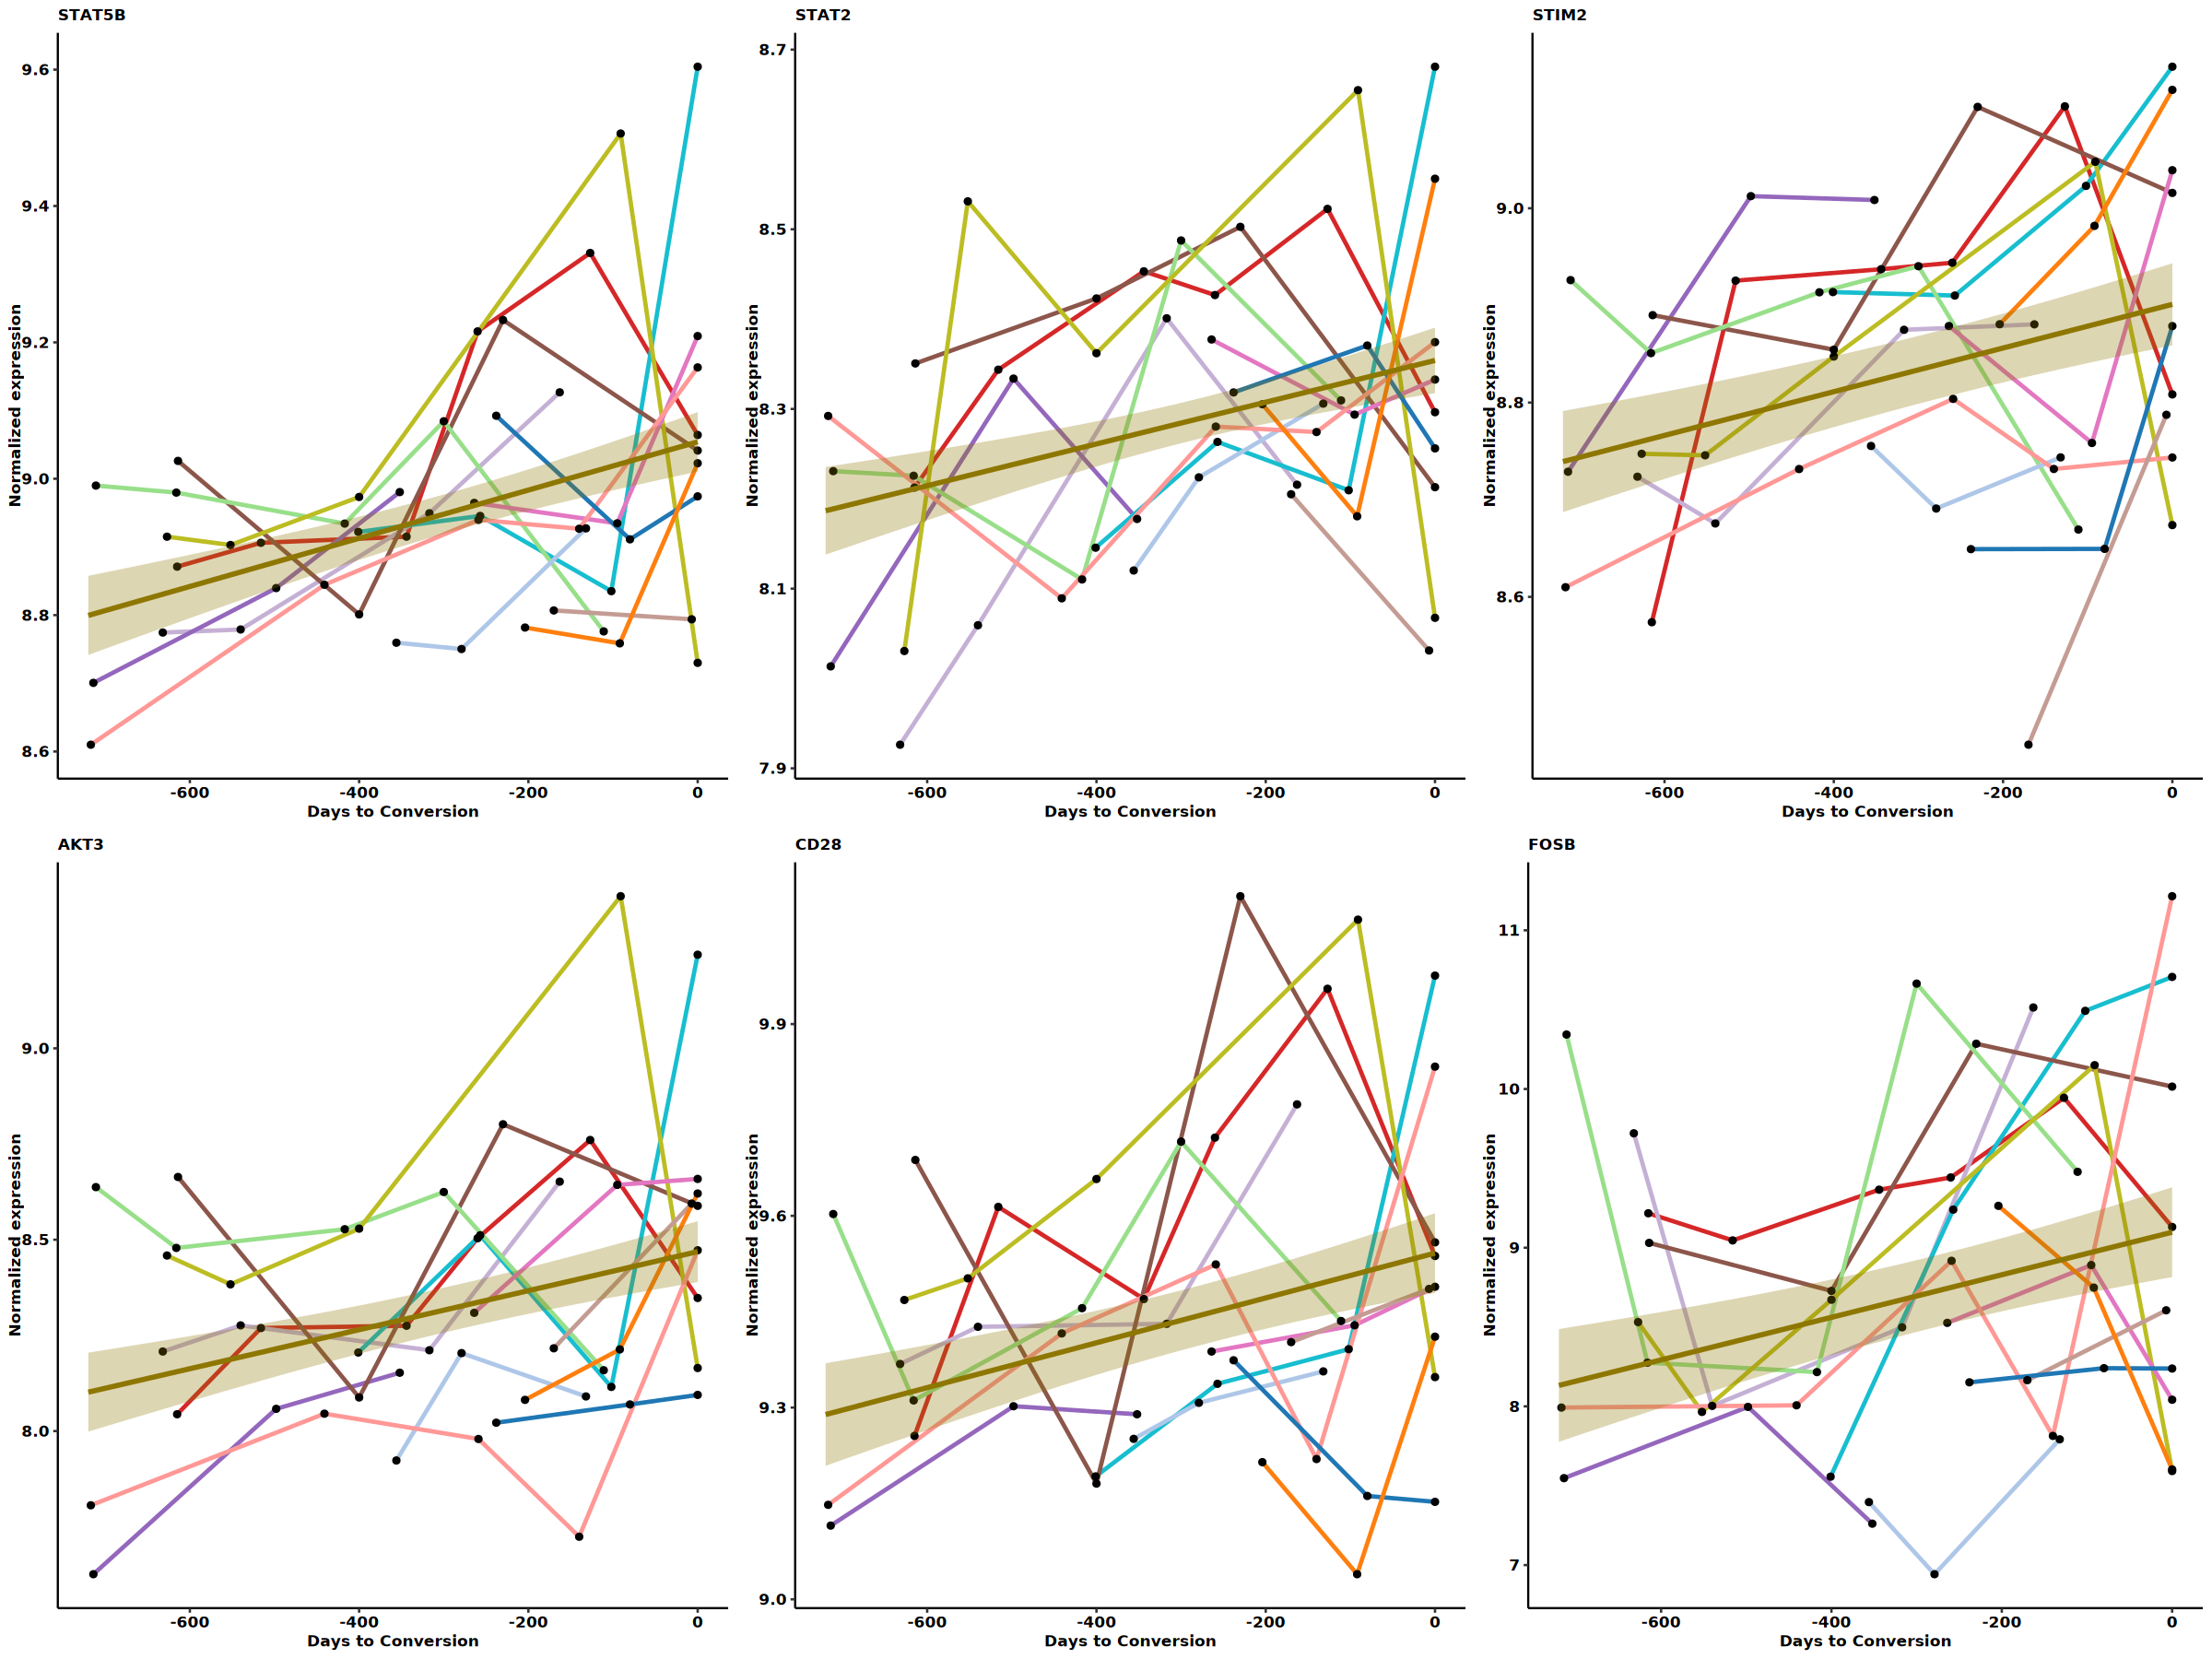

In [ ]:
cowplot::plot_grid(plotlist = p_list)
ggsave(file.path(fig_path, paste0(proj_name, "_selected_gene_model_expression.pdf")), width = 8, height = 8)


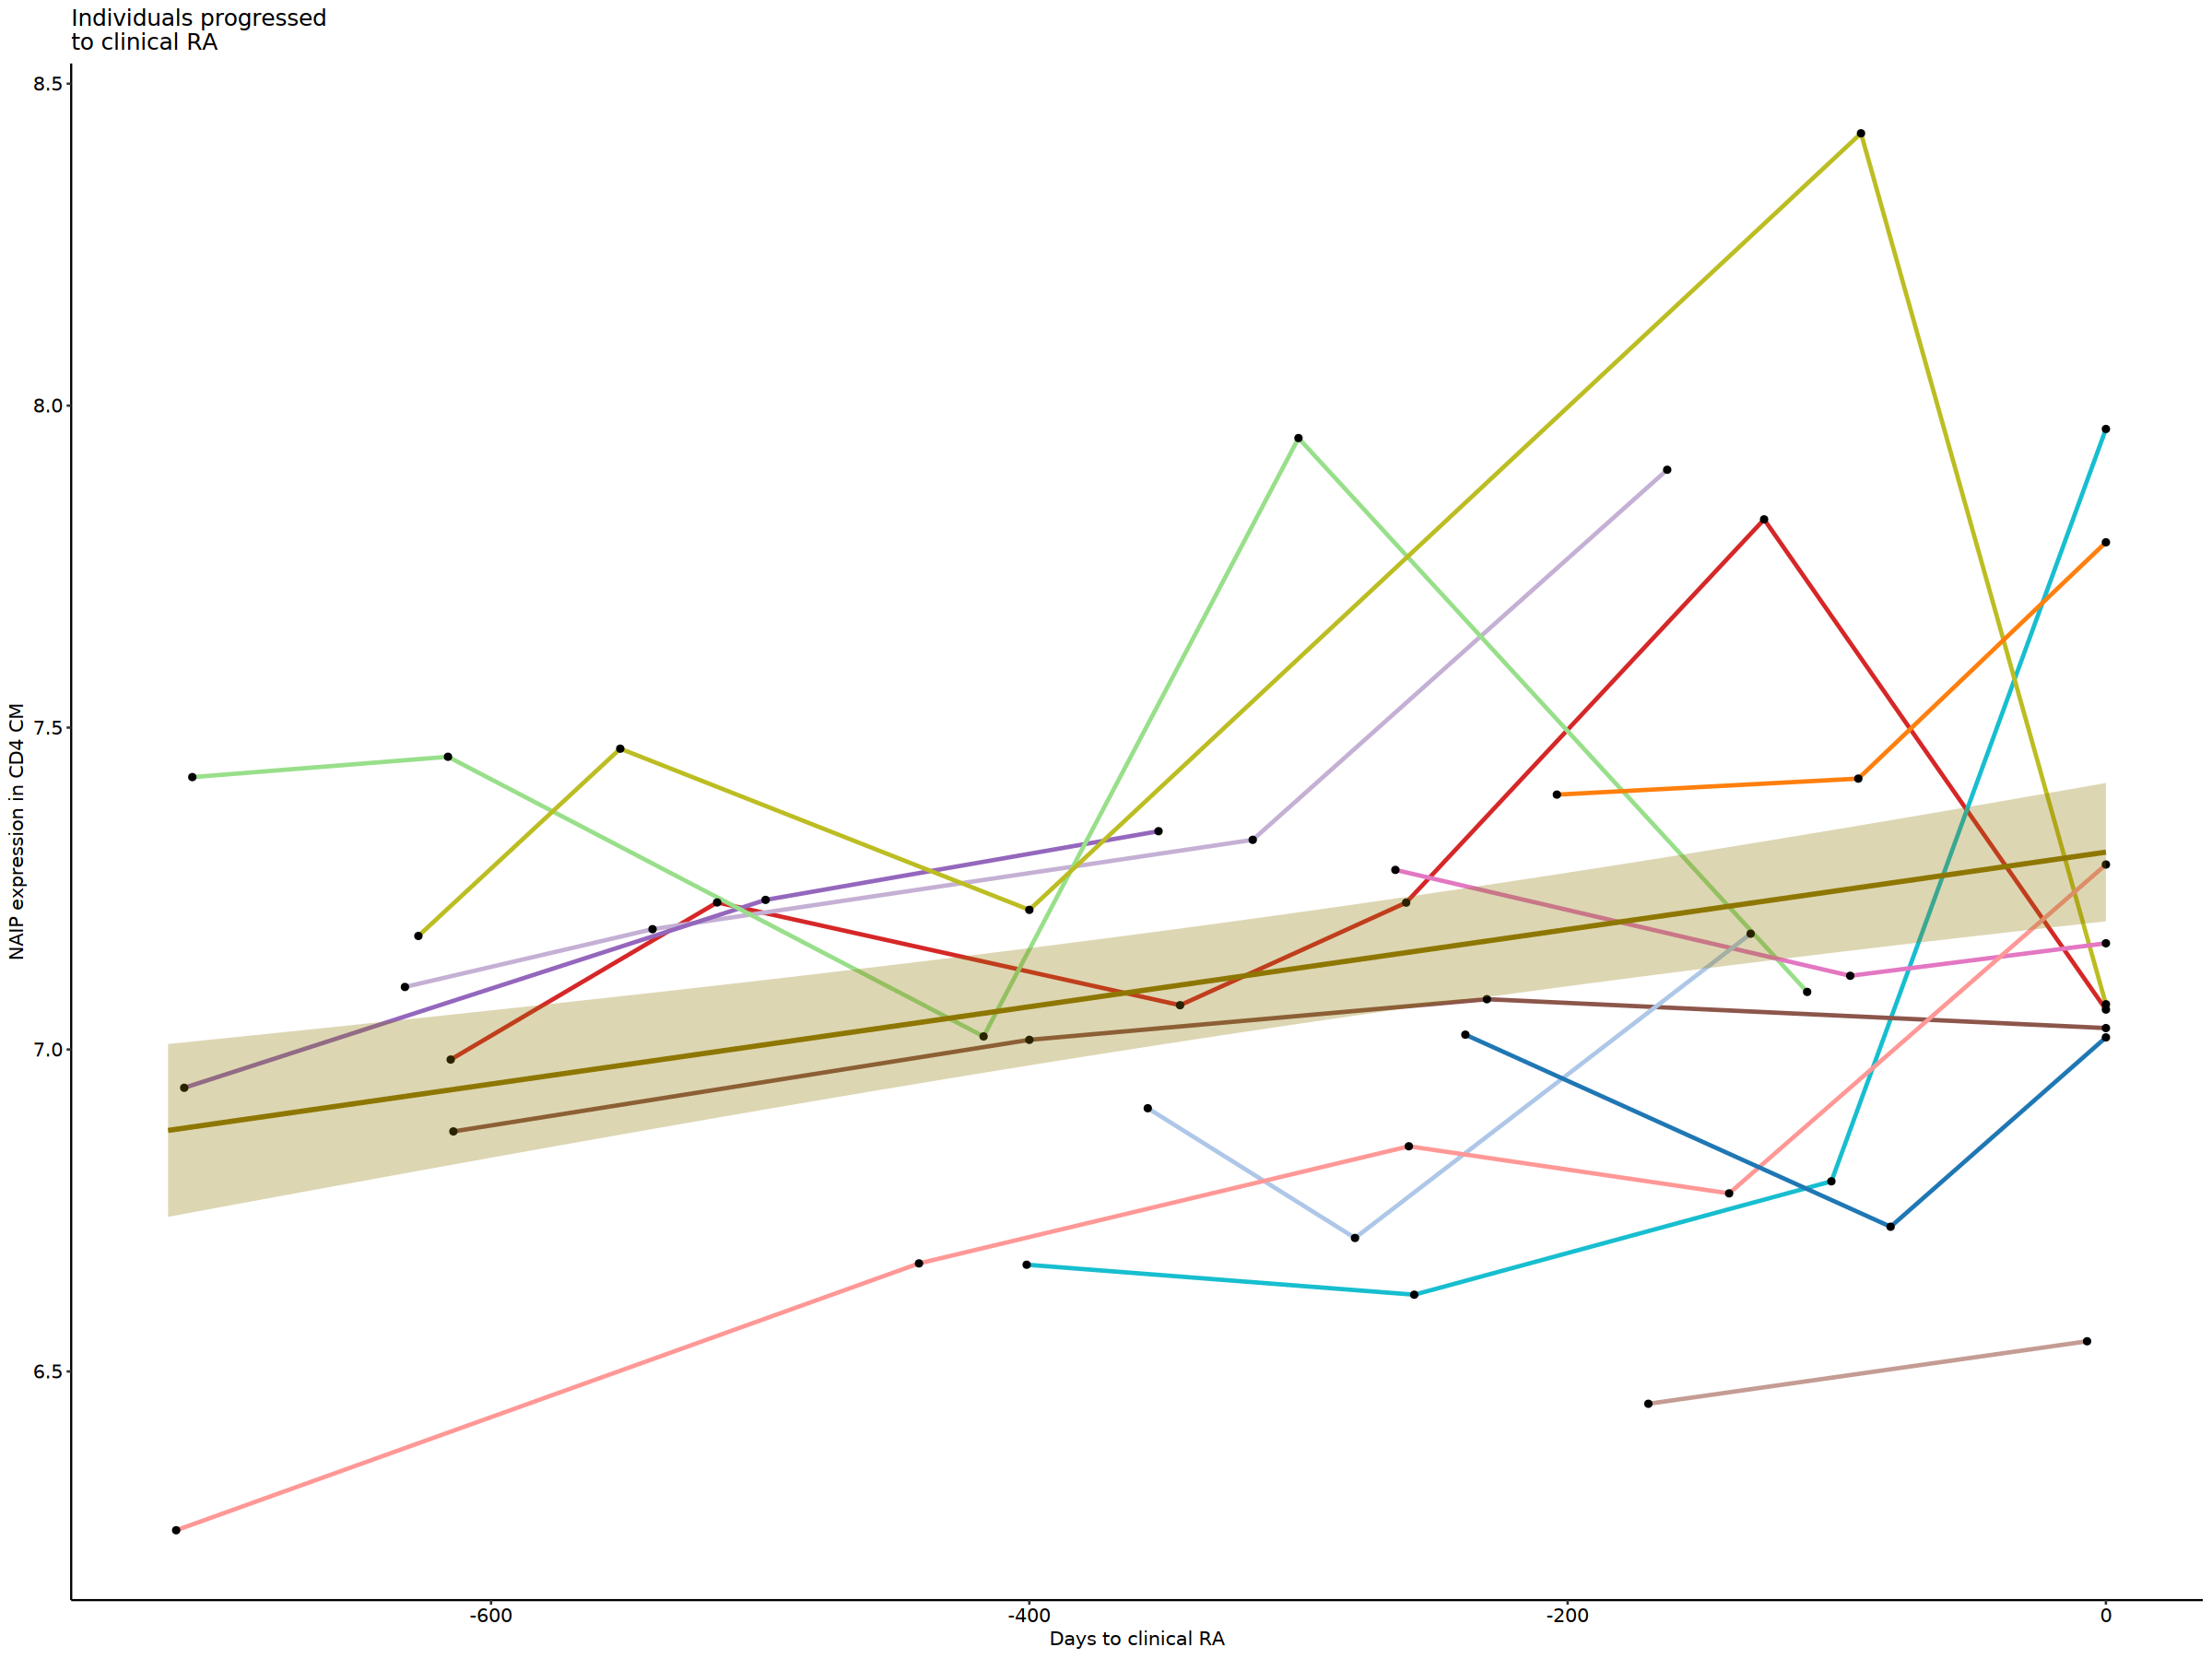

In [ ]:
gene_plot <- "NAIP"
p <- PlotPredLinePlot(aim3_cm_model[[gene_plot]],
  y_var = "count", shape_var = NULL,
  title = gene_plot, y_label = "NAIP expression in CD4 CM"
)
p + labs(
  title = "Individuals progressed\nto clinical RA",
  x = "Days to clinical RA"
)
ggsave(file.path(fig_path, paste0(proj_name, "_NAIP_model_expression.pdf")), width = 4, height = 4)


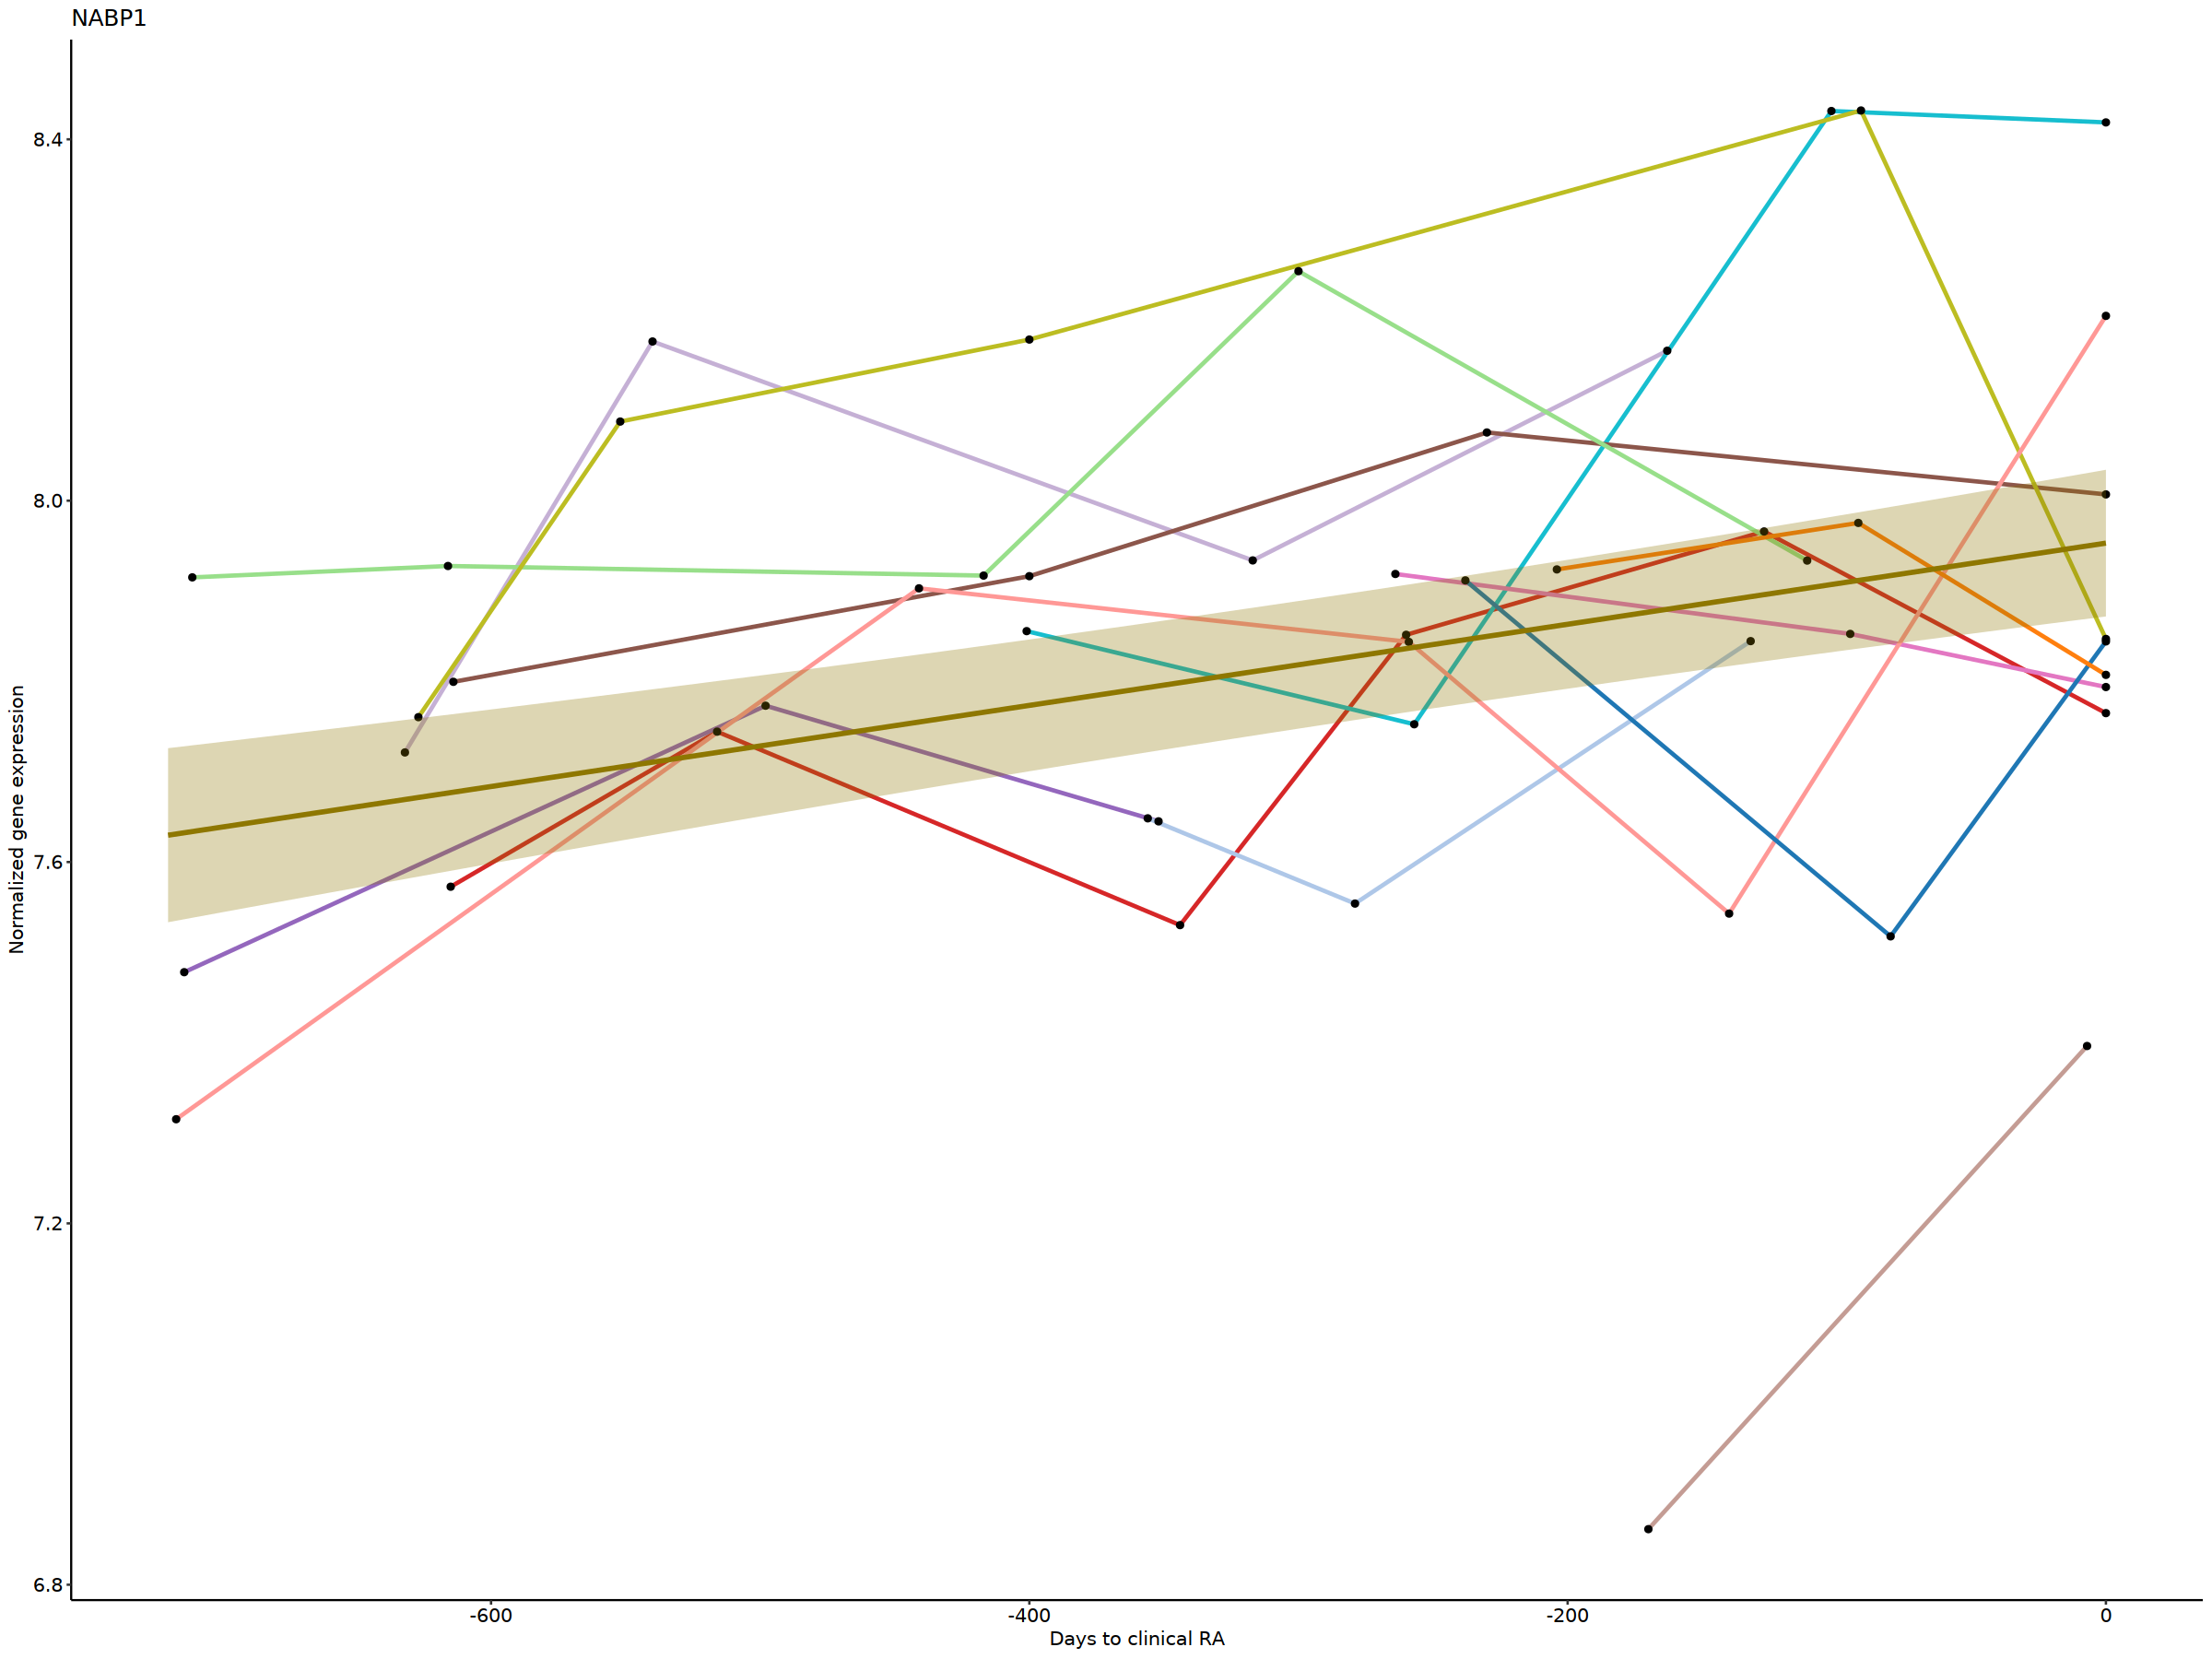

In [ ]:
gene_plot <- "NABP1"
p <- PlotPredLinePlot(aim3_cd4na_model[[gene_plot]],
  y_var = "count", shape_var = NULL,
  title = gene_plot, y_label = "Normalized gene expression"
)
p + labs(
  title = "NABP1",
  x = "Days to clinical RA"
)
ggsave(file.path(fig_path, paste0(proj_name, gene_plot, "_model_expression.pdf")), width = 3, height = 3)
